In [1]:
%load_ext autoreload 
%autoreload 2

In [2]:
import torch 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from fugw.mappings import FUGW
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, MutableMapping, Tuple
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "6"

In [31]:
from pathlib import Path
from src.align import *
from src.evaluate import *
from src.features import *
from src.process import *
from src.utils import *
from src.vis import *

In [18]:
family = load_family_data(Path("/home/bcl/wanghongyu/other/networkscience/data/NAPAbench/NAPAbenchVer2/benchmarkDataset/2way/CG/family1"))

2025-12-20 15:59:00,008 | INFO | src.process | Loaded A (3000 nodes, 11987 edges)
2025-12-20 15:59:00,205 | INFO | src.process | Loaded B (4000 nodes, 15987 edges)
2025-12-20 15:59:00,236 | INFO | src.process | Loaded A annotations (2195 nodes with FO labels)
2025-12-20 15:59:00,248 | INFO | src.process | Loaded B annotations (2190 nodes with FO labels)
2025-12-20 15:59:00,935 | INFO | src.process | Loaded similarity file A-B (62342 pairs)


In [24]:
feature_path = "/home/bcl/wanghongyu/other/networkscience/outputs/20251219_222827"
output_dir = "/home/bcl/wanghongyu/other/networkscience/outputs"
result = fugw_align(family.graphs["A"], family.graphs["B"], feature_path=feature_path, output_dir=output_dir)
pi = result["pi"].numpy()

2025-12-19 23:44:16,544 | INFO | src.align | Loaded cached features from /home/bcl/wanghongyu/other/networkscience/outputs/20251219_222827
2025-12-19 23:44:16,555 | INFO | src.align | Source features: (3000, 5), Target features: (4000, 5)
2025-12-19 23:44:16,555 | INFO | src.align | Source geometry: (3000, 3000), Target geometry: (4000, 4000)


[23:44:16] Validation data for feature maps is not provided. Using training data instead.              ]8;id=918924;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/mappings/dense.py\dense.py]8;;\:]8;id=40527;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/mappings/dense.py#199\199]8;;\

           Validation data for anatomical kernels is not provided. Using training data instead.        ]8;id=274954;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/mappings/dense.py\dense.py]8;;\:]8;id=410253;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/mappings/dense.py#226\226]8;;\

Output()

Output()

[23:44:27] BCD step 1/50   FUGW loss:      2.251373529434204       Validation loss:                    ]8;id=572943;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/solvers/dense.py\dense.py]8;;\:]8;id=422818;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/solvers/dense.py#521\521]8;;\
           2.251373529434204                                                                                       

Output()

Output()

KeyboardInterrupt: 

In [ ]:
sim_path = Path("/home/bcl/wanghongyu/other/networkscience/data/NAPAbench/NAPAbenchVer2/benchmarkDataset/2way/CG/family1/A-B.sim")

similarity_score = sim_score(sim_path=sim_path, 
coupling=pi,
source_nodes=result['source_nodes'],
target_nodes=result['target_nodes'])

FO_consistency_score = FO_consistency(coupling=pi,
source_nodes=result['source_nodes'],
target_nodes=result['target_nodes'],
source_annotations=family.annotations["A"],
target_annotations=family.annotations["B"],
)

topk_recall = topk_FO_recall(
    pi,
    result['source_nodes'],
    result['target_nodes'],
    family.annotations["A"],
    family.annotations["B"],
    k=5,
)

# Structural metrics
s3_h = S3_hard(family.graphs["A"], family.graphs["B"], pi, result['source_nodes'], result['target_nodes'])
s3_s = S3_soft(family.graphs["A"], family.graphs["B"], pi, result['source_nodes'], result['target_nodes'])

print(
    f"SIM={similarity_score:.4f}, FO_cons={FO_consistency_score:.4f}, "
    f"Top-k FO recall={topk_recall:.4f}, S3_hard={s3_h:.4f}, S3_soft={s3_s:.4f}"
)

SIM=68.6180, FO_cons=0.3361, Top-k FO recall=0.4180, S3_hard=0.1838, S3_soft=0.0000


In [4]:
from src.utils import (
    load_cached_features,
    METADATA_FILE,
    PARAMS_FILE,
    RESULTS_FILE,
    SOURCE_FEATURE_FILE,
    TARGET_FEATURE_FILE,
    SOURCE_GEOMETRY_FILE,
    TARGET_GEOMETRY_FILE,
    COUPLING_FILE,
)

run_dir = Path("outputs/20251219_231121")

# Option 1: high-level loader (returns AlignmentCache)
cache = load_cached_features(run_dir)
if cache:
    print("Feature tensor shape:", cache.source_features.shape)

# Option 2: manual access
metadata = json.loads((run_dir / METADATA_FILE).read_text(encoding="utf-8"))
params = json.loads((run_dir / PARAMS_FILE).read_text(encoding="utf-8"))
result = json.loads((run_dir / RESULTS_FILE).read_text(encoding="utf-8"))

source_features = torch.load(run_dir / SOURCE_FEATURE_FILE, map_location="cpu")
target_features = torch.load(run_dir / TARGET_FEATURE_FILE, map_location="cpu")
source_geometry = torch.load(run_dir / SOURCE_GEOMETRY_FILE, map_location="cpu")
target_geometry = torch.load(run_dir / TARGET_GEOMETRY_FILE, map_location="cpu")
coupling = torch.load(run_dir / COUPLING_FILE, map_location="cpu")

Feature tensor shape: torch.Size([3000, 5])


done


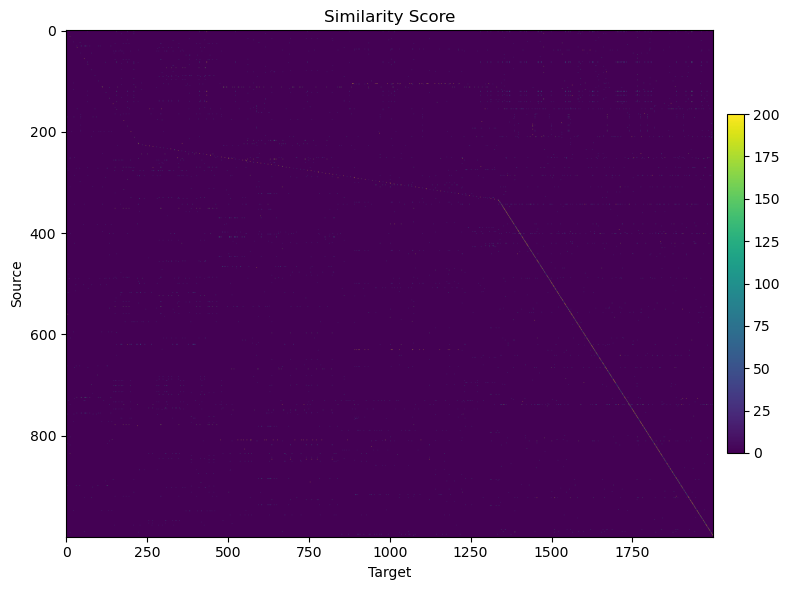

In [5]:
import src.evaluate as eval
sim_mat = eval._similarity_matrix_from_file("/home/bcl/wanghongyu/other/networkscience/data/NAPAbench/NAPAbenchVer2/benchmarkDataset/2way/CG/family1/A-B.sim", 
source_nodes=metadata.get("source_nodes", []), target_nodes=metadata.get("target_nodes", []))
plot_heatmap(np.clip(sim_mat[2000:,2000:,], 0, 200), title="Similarity Score")
print("done")

done


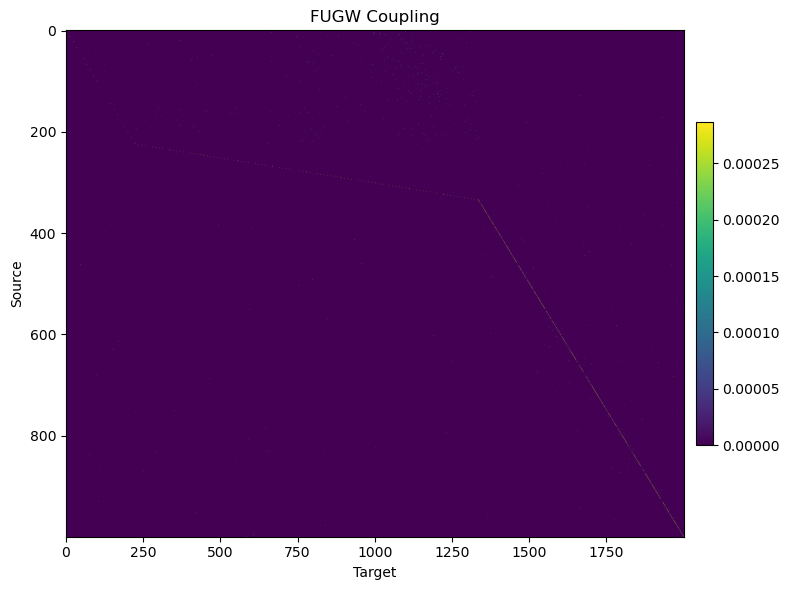

In [6]:
plot_heatmap(coupling[2000:,2000:,], title="FUGW Coupling")
print("done")

### Description

In [25]:
get_small_worldness(family.graphs["A"], n_iter=10)

2025-12-20 16:02:42,816 | INFO | src.process | Iteration: 0
2025-12-20 16:02:56,158 | INFO | src.process | Iteration: 1
2025-12-20 16:03:08,668 | INFO | src.process | Iteration: 2
2025-12-20 16:03:17,344 | INFO | src.process | Iteration: 3
2025-12-20 16:03:27,488 | INFO | src.process | Iteration: 4
2025-12-20 16:03:41,516 | INFO | src.process | Iteration: 5
2025-12-20 16:03:52,533 | INFO | src.process | Iteration: 6
2025-12-20 16:04:08,263 | INFO | src.process | Iteration: 7
2025-12-20 16:04:23,754 | INFO | src.process | Iteration: 8
2025-12-20 16:04:35,971 | INFO | src.process | Iteration: 9


(144.17988627834487, True)

In [26]:
get_clustering(family.graphs["A"], n_iter=10)

(180.10843405454065, True)

In [28]:
get_scale_free_ness(family.graphs["A"])

(3.2076900005340576, 0.8775003552436829, False)

In [32]:
get_scale_free_ness_clauset(family.graphs["A"])

(6.927142617215555, 15, 0.758, True)

### Old version

2025-12-10 15:55:47,127 | INFO | src.process | Loaded A (3000 nodes, 30910 edges)
2025-12-10 15:55:47,192 | INFO | src.process | Loaded B (4000 nodes, 44386 edges)
2025-12-10 15:55:47,194 | INFO | src.process | Loaded A annotations (2891 nodes with FO labels)
2025-12-10 15:55:47,196 | INFO | src.process | Loaded B annotations (3685 nodes with FO labels)
2025-12-10 15:55:47,258 | INFO | src.process | Loaded similarity file A-B (24716 pairs)


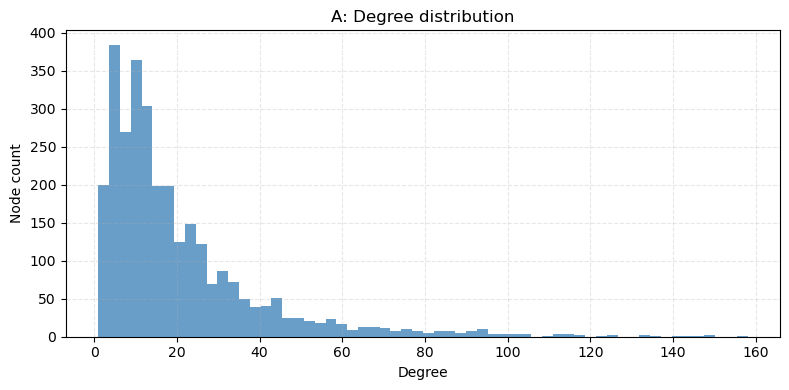

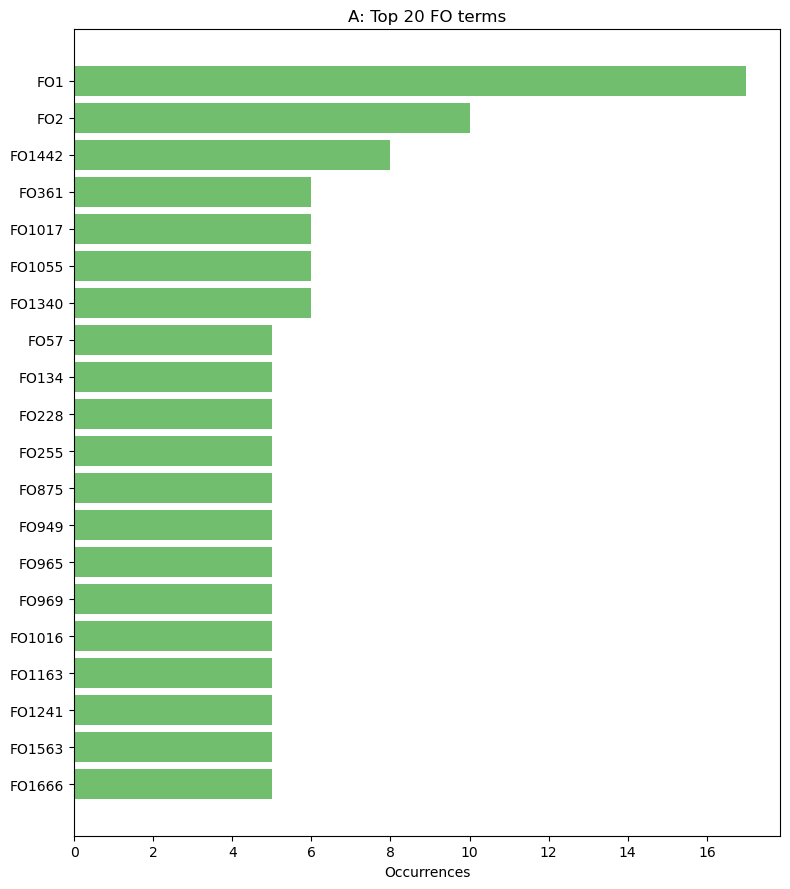

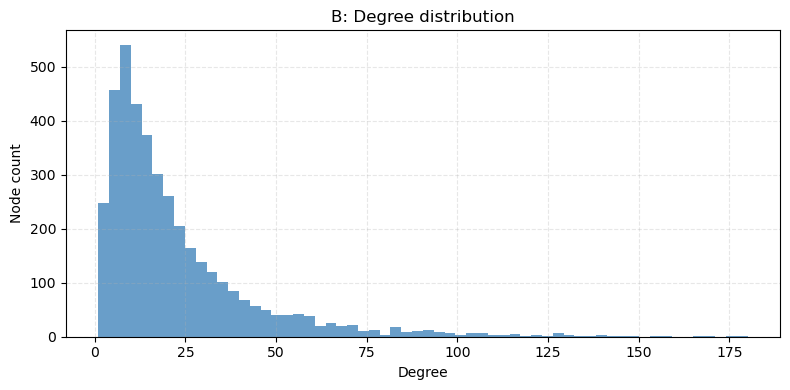

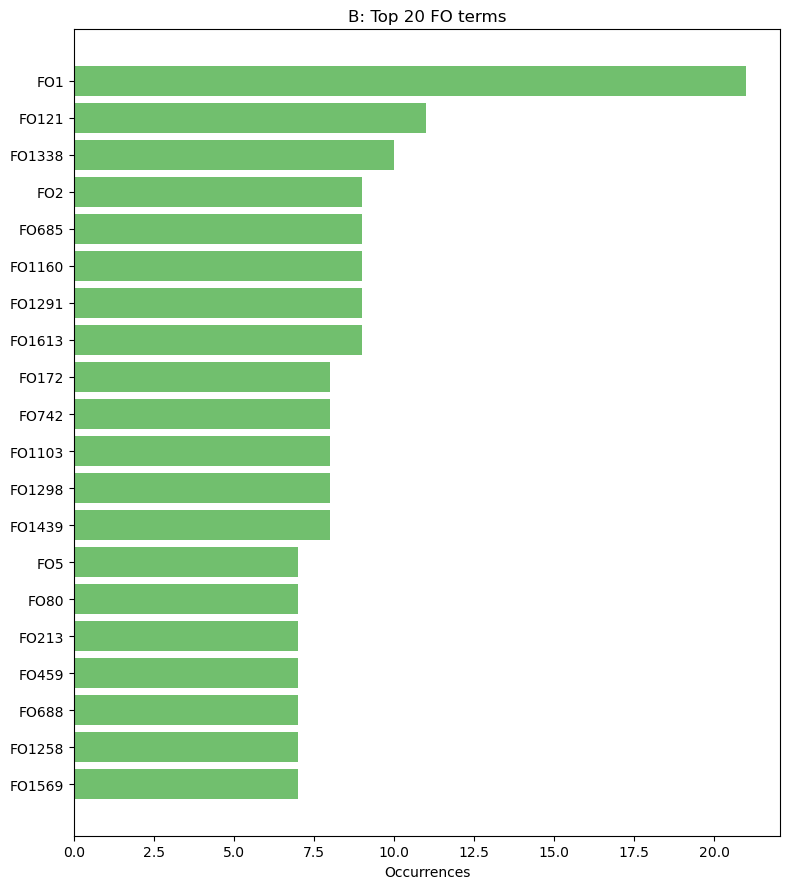

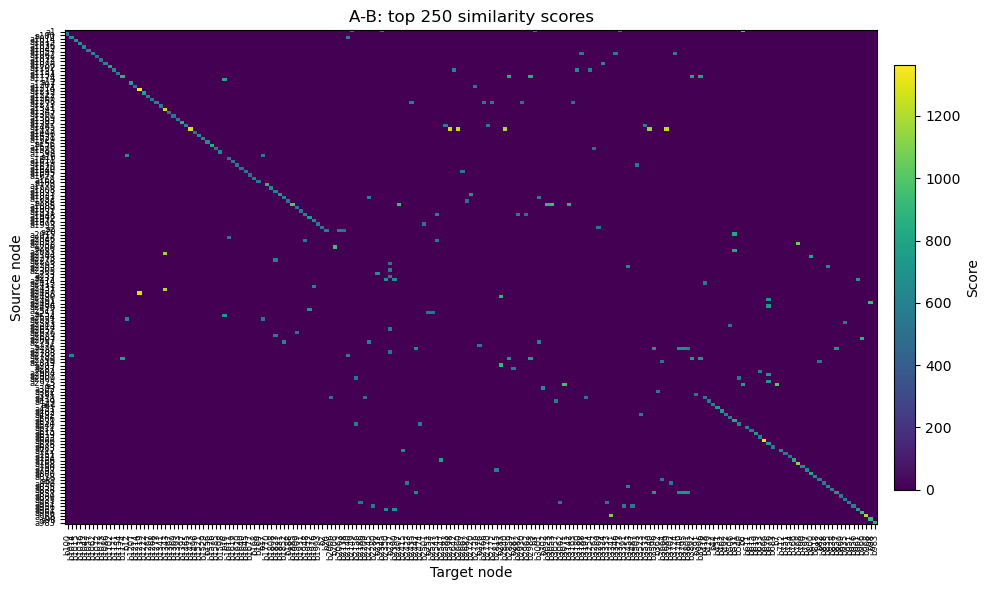

In [ ]:
sample_family = DATASET_ROOT / "2way" / "DMR" / "family1"
family_data = load_family_data(sample_family)
figures = visualize_family(family_data, similarity_pair=("A", "B"))

In [ ]:
family_dir = "/home/bcl/wanghongyu/other/networkscience/data/NAPAbench/NAPAbenchVer2/benchmarkDataset/2way/CG/family1"
result = align_family(family_dir=family_dir)

2025-12-10 15:58:59,178 | INFO | src.process | Loaded A (3000 nodes, 11987 edges)
2025-12-10 15:58:59,231 | INFO | src.process | Loaded B (4000 nodes, 15987 edges)
2025-12-10 15:58:59,234 | INFO | src.process | Loaded A annotations (2195 nodes with FO labels)
2025-12-10 15:58:59,238 | INFO | src.process | Loaded B annotations (2190 nodes with FO labels)
2025-12-10 15:58:59,950 | INFO | src.process | Loaded similarity file A-B (62342 pairs)


[15:59:44] Validation data for feature maps is not provided. Using  ]8;id=178333;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/mappings/dense.py\dense.py]8;;\:]8;id=271444;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/mappings/dense.py#199\199]8;;\
           training data instead.                                               
           Validation data for anatomical kernels is not provided.  ]8;id=918795;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/mappings/dense.py\dense.py]8;;\:]8;id=274813;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/mappings/dense.py#226\226]8;;\
           Using training data instead.                                         


Output()

Output()

[15:59:46] BCD step 1/10   FUGW loss:      1.0590718984603882       ]8;id=481808;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/solvers/dense.py\dense.py]8;;\:]8;id=268311;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/solvers/dense.py#521\521]8;;\
           Validation loss:        1.0590718984603882                           


...

Output()

[16:00:03] BCD step 9/10   FUGW loss:      0.8331555724143982       ]8;id=627813;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/solvers/dense.py\dense.py]8;;\:]8;id=202735;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/solvers/dense.py#521\521]8;;\
           Validation loss:        0.8331555724143982                           


Output()

Output()

[16:00:05] BCD step 10/10  FUGW loss:      0.8328344225883484       ]8;id=569432;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/solvers/dense.py\dense.py]8;;\:]8;id=484495;file:///home/bcl/wanghongyu/.conda/envs/network/lib/python3.11/site-packages/fugw/solvers/dense.py#521\521]8;;\
           Validation loss:        0.8328344225883484                           


In [ ]:
result.keys()

dict_keys(['pi', 'mapping', 'topk', 'metrics', 'source_nodes', 'target_nodes', 'feature_names', 'feature_weights'])

In [ ]:
result['metrics']

{'node_correctness': 0.4196666666666667,
 'recall_at_k': 0.46166666666666667,
 'precision_at_k': 0.09233333333333334,
 'edge_correctness': 0.37181947109368485,
 's3': 0.18952247310456266}